In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from copy import deepcopy
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Load the dataset
df = pd.read_csv('dataset/dynamic_resource_allocation_6G_with_target.csv')

# Basic data inspection
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['Target'].value_counts())


Dataset Shape: (1000, 18)

Column Names and Data Types:
Record_ID                            int64
Inventory_Level                      int64
Demand_Prediction                    int64
Network_Resource_Utilization       float64
Urgency_Level                        int64
Latency_ms                         float64
Bandwidth_Allocation_GB            float64
Real_Time_Adjustment                 int64
Order_Size                           int64
Transport_Status                     int64
System_Performance_Score             int64
Resource_Allocation_Strategy        object
6G_Network_Status                    int64
Task_Priority                       object
Energy_Consumption_kWh             float64
Shipment_Delay                     float64
Resource_Utilization_Efficiency    float64
Target                               int64
dtype: object

First few rows:
   Record_ID  Inventory_Level  Demand_Prediction  \
0          1             6036               2515   
1          2             8451      

In [35]:
# Detailed data exploration
print("=== NUMERIC COLUMNS SUMMARY ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[numeric_cols].describe().round(3))

print("\n=== CATEGORICAL COLUMNS ===")
print("Resource_Allocation_Strategy:", df['Resource_Allocation_Strategy'].value_counts())
print("\nTask_Priority:", df['Task_Priority'].value_counts())

print("\n=== TARGET BY STRATEGY ===")
print(pd.crosstab(df['Resource_Allocation_Strategy'], df['Target'], margins=True))

print("\n=== TARGET BY TASK PRIORITY ===")
print(pd.crosstab(df['Task_Priority'], df['Target'], margins=True))

print("\n=== CORRELATION WITH TARGET ===")
correlations = df[numeric_cols].corr()['Target'].sort_values(ascending=False)
print(correlations.round(4))


=== NUMERIC COLUMNS SUMMARY ===
       Record_ID  Inventory_Level  Demand_Prediction  \
count   1000.000         1000.000           1000.000   
mean     500.500         5029.746           4970.721   
std      288.819         2822.581           2746.085   
min        1.000          100.000            107.000   
25%      250.750         2489.000           2734.750   
50%      500.500         5153.500           5030.500   
75%      750.250         7488.250           7237.250   
max     1000.000         9979.000           9975.000   

       Network_Resource_Utilization  Urgency_Level  Latency_ms  \
count                      1000.000       1000.000    1000.000   
mean                         50.489          1.032      55.774   
std                          23.213          0.818      25.499   
min                          10.047          0.000      10.049   
25%                          30.428          0.000      34.086   
50%                          50.743          1.000      56.413   
7

In [36]:

# The real-world problem: Optimize 6G network resource allocation to maximize system performance
# while minimizing latency and energy consumption

# ============================================================
# PROBLEM DEFINITION
# ============================================================
# Decision Variables (continuous and discrete):
# x1: Network_Resource_Utilization (%) [10, 90]
# x2: Bandwidth_Allocation_GB [1, 100]
# x3: Latency_ms [10, 100] (to MINIMIZE)
# x4: Energy_Consumption_kWh [10, 1000] (to MINIMIZE)
# x5: Resource_Utilization_Efficiency (%) [50, 100] (to MAXIMIZE)
# x6: System_Performance_Score [50, 99] (to MAXIMIZE)
# x7: Real_Time_Adjustment {0, 1}
# x8: Urgency_Level {0, 1, 2}

# We define the optimization problem based on the dataset patterns
# Goal: Find optimal resource allocation configuration that achieves Target=1
# (optimal allocation) while balancing multiple objectives

# Extract feature ranges from data
feature_ranges = {
    'Network_Resource_Utilization': (df['Network_Resource_Utilization'].min(), df['Network_Resource_Utilization'].max()),
    'Bandwidth_Allocation_GB': (df['Bandwidth_Allocation_GB'].min(), df['Bandwidth_Allocation_GB'].max()),
    'Latency_ms': (df['Latency_ms'].min(), df['Latency_ms'].max()),
    'Energy_Consumption_kWh': (df['Energy_Consumption_kWh'].min(), df['Energy_Consumption_kWh'].max()),
    'Resource_Utilization_Efficiency': (df['Resource_Utilization_Efficiency'].min(), df['Resource_Utilization_Efficiency'].max()),
    'System_Performance_Score': (df['System_Performance_Score'].min(), df['System_Performance_Score'].max()),
    'Inventory_Level': (df['Inventory_Level'].min(), df['Inventory_Level'].max()),
    'Demand_Prediction': (df['Demand_Prediction'].min(), df['Demand_Prediction'].max()),
}

print("Feature Ranges from Dataset:")
for k, v in feature_ranges.items():
    print(f"  {k}: [{v[0]:.2f}, {v[1]:.2f}]")

# Define the optimization problem class
class ResourceAllocationProblem:
    """
    6G Dynamic Resource Allocation Optimization Problem
    
    Multi-objective optimization:
    1. Minimize Latency (critical for 6G real-time applications)
    2. Minimize Energy Consumption (sustainability)
    3. Maximize System Performance Score
    4. Maximize Resource Utilization Efficiency
    5. Satisfy Demand (Inventory >= Demand)
    """
    
    def __init__(self):
        # Decision variable bounds
        self.bounds = {
            'network_util': (10, 90),      # Network Resource Utilization %
            'bandwidth': (1, 100),          # Bandwidth Allocation GB
            'latency': (10, 100),           # Latency ms (minimize)
            'energy': (10, 1000),           # Energy Consumption kWh (minimize)
            'efficiency': (50, 100),        # Resource Utilization Efficiency %
            'performance': (50, 99),        # System Performance Score
            'inventory': (100, 10000),      # Inventory Level
            'demand': (100, 10000),         # Demand Prediction
            'real_time': (0, 1),            # Real-time Adjustment (binary)
            'urgency': (0, 2),              # Urgency Level (0-2)
        }
        
        # Weights for multi-objective (from domain knowledge)
        self.w_latency = 0.30       # Latency weight (critical for 6G)
        self.w_energy = 0.20      # Energy weight (green 6G)
        self.w_performance = 0.25  # Performance weight
        self.w_efficiency = 0.15  # Efficiency weight
        self.w_demand = 0.10      # Demand satisfaction weight
        
    def decode_solution(self, chromosome):
        """Decode chromosome to decision variables"""
        solution = {}
        idx = 0
        for key, (lb, ub) in self.bounds.items():
            if key in ['real_time', 'urgency']:
                # Integer variables
                solution[key] = int(np.round(chromosome[idx]))
            else:
                # Continuous variables
                solution[key] = np.clip(chromosome[idx], lb, ub)
            idx += 1
        return solution
    
    def objective_function(self, chromosome):
        """
        Multi-objective fitness function
        Returns: fitness value (higher is better)
        """
        sol = self.decode_solution(chromosome)
        
        # Objective 1: Minimize Latency (normalized, inverted for maximization)
        f_latency = 1 - ((sol['latency'] - 10) / 90)
        
        # Objective 2: Minimize Energy (normalized, inverted)
        f_energy = 1 - ((sol['energy'] - 10) / 990)
        
        # Objective 3: Maximize Performance
        f_performance = (sol['performance'] - 50) / 49
        
        # Objective 4: Maximize Efficiency
        f_efficiency = (sol['efficiency'] - 50) / 50
        
        # Objective 5: Demand satisfaction (inventory >= demand)
        demand_ratio = sol['inventory'] / max(sol['demand'], 1)
        f_demand = min(demand_ratio, 2.0) / 2.0  # Cap at 2x
        
        # Penalty for constraint violation
        penalty = 0
        
        # Hard constraint: latency must be < 50ms for critical 6G applications
        if sol['urgency'] == 2 and sol['latency'] > 50:
            penalty += 0.3 * (sol['latency'] - 50) / 50
            
        # Hard constraint: energy should not exceed 800 kWh for sustainability
        if sol['energy'] > 800:
            penalty += 0.2 * (sol['energy'] - 800) / 200
            
        # Soft constraint: network utilization should be 40-80%
        if sol['network_util'] < 30 or sol['network_util'] > 85:
            penalty += 0.1
            
        # Soft constraint: efficiency should be > 70%
        if sol['efficiency'] < 70:
            penalty += 0.15 * (70 - sol['efficiency']) / 70
        
        # Combined weighted objective
        fitness = (self.w_latency * f_latency + 
                   self.w_energy * f_energy +
                   self.w_performance * f_performance +
                   self.w_efficiency * f_efficiency +
                   self.w_demand * f_demand)
        
        # Apply penalty
        fitness = max(0, fitness - penalty)
        
        return fitness, {
            'latency_score': f_latency,
            'energy_score': f_energy,
            'performance_score': f_performance,
            'efficiency_score': f_efficiency,
            'demand_score': f_demand,
            'penalty': penalty,
            'solution': sol
        }

problem = ResourceAllocationProblem()
print("\nProblem initialized successfully!")
print("Number of decision variables:", len(problem.bounds))


Feature Ranges from Dataset:
  Network_Resource_Utilization: [10.05, 89.95]
  Bandwidth_Allocation_GB: [1.06, 99.98]
  Latency_ms: [10.05, 99.85]
  Energy_Consumption_kWh: [11.26, 997.52]
  Resource_Utilization_Efficiency: [50.02, 99.97]
  System_Performance_Score: [50.00, 99.00]
  Inventory_Level: [100.00, 9979.00]
  Demand_Prediction: [107.00, 9975.00]

Problem initialized successfully!
Number of decision variables: 10


In [37]:
# ============================================================
# ANT COLONY OPTIMIZATION (ACO) IMPLEMENTATION
# ============================================================

class ACO:
    """
    Ant Colony Optimization for continuous optimization
    Using Gaussian kernel-based probability distribution (CACO approach)
    """
    
    def __init__(self, problem:ResourceAllocationProblem, n_ants=30, n_iterations=100, 
                 alpha=1.0, beta=2.0, rho=0.1, Q=100):
        """
        Parameters:
        - n_ants: Number of ants
        - n_iterations: Number of iterations
        - alpha: Pheromone importance
        - beta: Heuristic importance
        - rho: Pheromone evaporation rate
        - Q: Pheromone deposit constant
        """
        self.problem = problem
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.Q = Q
        
        self.n_vars = len(problem.bounds)
        self.bounds_list = list(problem.bounds.values())
        
        # Initialize pheromone matrix (one per variable, discretized)
        self.n_bins = 20  # Discretization bins for pheromone
        self.pheromone = [np.ones(self.n_bins) for _ in range(self.n_vars)]
        
        # Best solution tracking
        self.best_solution = None
        self.best_fitness = -np.inf
        self.best_history = []
        self.avg_history = []
        self.worst_history = []
        
    def _decode_bin(self, var_idx, bin_idx):
        """Convert bin index to actual value"""
        lb, ub = self.bounds_list[var_idx]
        return lb + (bin_idx / (self.n_bins - 1)) * (ub - lb)
    
    def _value_to_bin(self, var_idx, value):
        """Convert value to bin index"""
        lb, ub = self.bounds_list[var_idx]
        bin_idx = int(((value - lb) / (ub - lb)) * (self.n_bins - 1))
        return np.clip(bin_idx, 0, self.n_bins - 1)
    
    def _construct_solution(self):
        """Each ant constructs a solution based on pheromone and heuristic"""
        solution = np.zeros(self.n_vars)
        
        for i in range(self.n_vars):
            # Calculate selection probability
            tau = self.pheromone[i] ** self.alpha
            
            # Heuristic information (prefer middle values for continuous vars)
            eta = np.ones(self.n_bins)
            for b in range(self.n_bins):
                val = self._decode_bin(i, b)
                lb, ub = self.bounds_list[i]
                # Prefer values away from extremes (normalized)
                eta[b] = 1.0 - abs((val - (lb + ub)/2) / ((ub - lb)/2))
            eta = eta ** self.beta
            
            # Combined probability
            prob = tau * eta
            prob = prob / prob.sum()
            
            # Select bin using roulette wheel
            bin_idx = np.random.choice(self.n_bins, p=prob)
            
            # Add some Gaussian noise for exploration
            val = self._decode_bin(i, bin_idx)
            lb, ub = self.bounds_list[i]
            noise = np.random.normal(0, (ub - lb) / self.n_bins)
            solution[i] = np.clip(val + noise, lb, ub)
            
        return solution
    
    def _update_pheromone(self, solutions, fitnesses):
        """Update pheromone trails"""
        # Evaporation
        for i in range(self.n_vars):
            self.pheromone[i] *= (1 - self.rho)
        
        # Deposit new pheromone (only from top 30% ants)
        sorted_idx = np.argsort(fitnesses)[::-1]
        n_elite = max(1, int(0.3 * self.n_ants))
        
        for rank, idx in enumerate(sorted_idx[:n_elite]):
            sol = solutions[idx]
            fit = fitnesses[idx]
            
            for i in range(self.n_vars):
                bin_idx = self._value_to_bin(i, sol[i])
                # More pheromone for better solutions
                deposit = self.Q * fit / (rank + 1)
                # Spread to neighboring bins
                for j in range(max(0, bin_idx-1), min(self.n_bins, bin_idx+2)):
                    self.pheromone[i][j] += deposit * (1 - abs(j - bin_idx) * 0.3)
                
        # Ensure pheromone stays positive
        for i in range(self.n_vars):
            self.pheromone[i] = np.maximum(self.pheromone[i], 0.1)
    
    def optimize(self):
        """Main ACO optimization loop"""
        start_time = time.time()
        
        for iteration in range(self.n_iterations):
            solutions = []
            fitnesses = []
            details_list = []
            
            # Each ant builds a solution
            for ant in range(self.n_ants):
                sol = self._construct_solution()
                fit, details = self.problem.objective_function(sol)
                solutions.append(sol)
                fitnesses.append(fit)
                details_list.append(details)
            
            fitnesses = np.array(fitnesses)
            
            # Update best
            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = fitnesses[best_idx]
                self.best_solution = solutions[best_idx].copy()
                self.best_details = details_list[best_idx]
            
            # Update pheromone
            self._update_pheromone(solutions, fitnesses)
            
            # Record history
            self.best_history.append(self.best_fitness)
            self.avg_history.append(np.mean(fitnesses))
            self.worst_history.append(np.min(fitnesses))
            
        self.runtime = time.time() - start_time
        return self.best_solution, self.best_fitness

# Test ACO
print("Running ACO optimization...")
aco = ACO(problem, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0, rho=0.1, Q=100)
aco_best_sol, aco_best_fit = aco.optimize()
print(f"ACO Best Fitness: {aco_best_fit:.6f}")
print(f"ACO Runtime: {aco.runtime:.3f} seconds")
print(f"ACO Best Solution Details:")
for k, v in aco.best_details['solution'].items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")


Running ACO optimization...
ACO Best Fitness: 0.833303
ACO Runtime: 1.456 seconds
ACO Best Solution Details:
  network_util: 43.96
  bandwidth: 55.82
  latency: 15.31
  energy: 85.33
  efficiency: 80.10
  performance: 87.34
  inventory: 5630.32
  demand: 3295.66
  real_time: 0
  urgency: 1


In [38]:
# ============================================================
# GENETIC ALGORITHM (GA) IMPLEMENTATION
# ============================================================

class GA:
    """
    Genetic Algorithm for 6G Resource Allocation Optimization
    """
    
    def __init__(self, problem:ResourceAllocationProblem, pop_size=50, n_generations=100,
                 crossover_rate=0.8, mutation_rate=0.1,
                 elitism=0.1, tournament_size=3):
        """
        Parameters:
        - pop_size: Population size
        - n_generations: Number of generations
        - crossover_rate: Probability of crossover
        - mutation_rate: Probability of mutation
        - elitism: Fraction of elite individuals preserved
        - tournament_size: Tournament selection size
        """
        self.problem = problem
        self.pop_size = pop_size
        self.n_generations = n_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elitism = elitism
        self.tournament_size = tournament_size
        
        self.n_vars = len(problem.bounds)
        self.bounds_list = list(problem.bounds.values())
        
        # Tracking
        self.best_solution = None
        self.best_fitness = -np.inf
        self.best_history = []
        self.avg_history = []
        self.worst_history = []
        self.diversity_history = []
        
    def _initialize_population(self):
        """Random initialization within bounds"""
        pop = np.zeros((self.pop_size, self.n_vars))
        for i in range(self.n_vars):
            lb, ub = self.bounds_list[i]
            pop[:, i] = np.random.uniform(lb, ub, self.pop_size)
        return pop
    
    def _evaluate_population(self, population):
        """Evaluate fitness for entire population"""
        fitnesses = []
        details_list = []
        for individual in population:
            fit, details = self.problem.objective_function(individual)
            fitnesses.append(fit)
            details_list.append(details)
        return np.array(fitnesses), details_list
    
    def _tournament_selection(self, population, fitnesses):
        """Tournament selection"""
        selected = []
        for _ in range(self.pop_size):
            # Randomly select tournament participants
            idx = np.random.choice(self.pop_size, self.tournament_size, replace=False)
            winner_idx = idx[np.argmax(fitnesses[idx])]
            selected.append(population[winner_idx].copy())
        return np.array(selected)
    
    def _crossover(self, parent1, parent2):
        """Simulated Binary Crossover (SBX)"""
        if np.random.random() > self.crossover_rate:
            return parent1.copy(), parent2.copy()
        
        child1 = np.zeros(self.n_vars)
        child2 = np.zeros(self.n_vars)
        
        eta = 20  # Distribution index
        
        for i in range(self.n_vars):
            if np.random.random() <= 0.5:
                # Perform crossover
                if abs(parent1[i] - parent2[i]) > 1e-14:
                    if parent1[i] < parent2[i]:
                        y1, y2 = parent1[i], parent2[i]
                    else:
                        y1, y2 = parent2[i], parent1[i]
                    
                    lb, ub = self.bounds_list[i]
                    beta = 1.0 + (2.0 * (y1 - lb) / (y2 - y1))
                    alpha = 2.0 - beta ** (-(eta + 1))
                    
                    rand = np.random.random()
                    if rand <= 1.0 / alpha:
                        beta_q = (rand * alpha) ** (1.0 / (eta + 1))
                    else:
                        beta_q = (1.0 / (2.0 - rand * alpha)) ** (1.0 / (eta + 1))
                    
                    c1 = 0.5 * ((y1 + y2) - beta_q * (y2 - y1))
                    
                    beta = 1.0 + (2.0 * (ub - y2) / (y2 - y1))
                    alpha = 2.0 - beta ** (-(eta + 1))
                    
                    if rand <= 1.0 / alpha:
                        beta_q = (rand * alpha) ** (1.0 / (eta + 1))
                    else:
                        beta_q = (1.0 / (2.0 - rand * alpha)) ** (1.0 / (eta + 1))
                    
                    c2 = 0.5 * ((y1 + y2) + beta_q * (y2 - y1))
                    
                    c1 = np.clip(c1, lb, ub)
                    c2 = np.clip(c2, lb, ub)
                    
                    if np.random.random() <= 0.5:
                        child1[i] = c1
                        child2[i] = c2
                    else:
                        child1[i] = c2
                        child2[i] = c1
                else:
                    child1[i] = parent1[i]
                    child2[i] = parent2[i]
            else:
                child1[i] = parent1[i]
                child2[i] = parent2[i]
        
        return child1, child2
    
    def _mutation(self, individual):
        """Polynomial Mutation"""
        mutant = individual.copy()
        eta_m = 20  # Mutation distribution index
        
        for i in range(self.n_vars):
            if np.random.random() < self.mutation_rate:
                lb, ub = self.bounds_list[i]
                delta1 = (mutant[i] - lb) / (ub - lb)
                delta2 = (ub - mutant[i]) / (ub - lb)
                
                rand = np.random.random()
                mut_pow = 1.0 / (eta_m + 1.0)
                
                if rand <= 0.5:
                    xy = 1.0 - delta1
                    val = 2.0 * rand + (1.0 - 2.0 * rand) * (xy ** (eta_m + 1))
                    delta_q = val ** mut_pow - 1.0
                else:
                    xy = 1.0 - delta2
                    val = 2.0 * (1.0 - rand) + 2.0 * (rand - 0.5) * (xy ** (eta_m + 1))
                    delta_q = 1.0 - val ** mut_pow
                
                mutant[i] += delta_q * (ub - lb)
                mutant[i] = np.clip(mutant[i], lb, ub)
        
        return mutant
    
    def optimize(self):
        """Main GA optimization loop"""
        start_time = time.time()
        
        # Initialize
        population = self._initialize_population()
        fitnesses, details_list = self._evaluate_population(population)
        
        # Track best
        best_idx = np.argmax(fitnesses)
        self.best_fitness = fitnesses[best_idx]
        self.best_solution = population[best_idx].copy()
        self.best_details = details_list[best_idx]
        
        n_elite = max(1, int(self.elitism * self.pop_size))
        
        for generation in range(self.n_generations):
            # Elitism: preserve top individuals
            sorted_idx = np.argsort(fitnesses)[::-1]
            elite = [population[idx].copy() for idx in sorted_idx[:n_elite]]
            
            # Selection
            selected = self._tournament_selection(population, fitnesses)
            
            # Crossover and mutation
            offspring = []
            for i in range(0, self.pop_size - n_elite, 2):
                parent1 = selected[i]
                parent2 = selected[min(i+1, self.pop_size - n_elite - 1)]
                child1, child2 = self._crossover(parent1, parent2)
                child1 = self._mutation(child1)
                child2 = self._mutation(child2)
                offspring.extend([child1, child2])
            
            # Ensure correct population size
            offspring = offspring[:self.pop_size - n_elite]
            
            # Create new population
            population = np.vstack([np.array(elite), np.array(offspring)])
            
            # Evaluate new population
            fitnesses, details_list = self._evaluate_population(population)
            
            # Update best
            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = fitnesses[best_idx]
                self.best_solution = population[best_idx].copy()
                self.best_details = details_list[best_idx]
            
            # Record history
            self.best_history.append(self.best_fitness)
            self.avg_history.append(np.mean(fitnesses))
            self.worst_history.append(np.min(fitnesses))
            
            # Population diversity
            diversity = np.mean(np.std(population, axis=0))
            self.diversity_history.append(diversity)
        
        self.runtime = time.time() - start_time
        return self.best_solution, self.best_fitness

# Test GA
print("Running GA optimization...")
ga = GA(problem, pop_size=50, n_generations=100, 
        crossover_rate=0.8, mutation_rate=0.15, 
        elitism=0.1, tournament_size=3)
ga_best_sol, ga_best_fit = ga.optimize()
print(f"GA Best Fitness: {ga_best_fit:.6f}")
print(f"GA Runtime: {ga.runtime:.3f} seconds")
print(f"GA Best Solution Details:")
for k, v in ga.best_details['solution'].items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")


Running GA optimization...
GA Best Fitness: 1.000000
GA Runtime: 0.424 seconds
GA Best Solution Details:
  network_util: 41.19
  bandwidth: 45.19
  latency: 10.00
  energy: 10.00
  efficiency: 100.00
  performance: 99.00
  inventory: 5577.33
  demand: 172.07
  real_time: 1
  urgency: 0


In [39]:
# ============================================================
# ACO + GA HYBRID ALGORITHM
# ============================================================

class ACO_GA_Hybrid:
    """
    Hybrid ACO-GA Algorithm for 6G Resource Allocation
    
    Phase 1: ACO explores the search space and identifies promising regions
    Phase 2: GA refines solutions using crossover and mutation
    Phase 3: ACO uses GA-best solutions to update pheromone
    """
    
    def __init__(self, problem:ResourceAllocationProblem, 
                 aco_ants=30, aco_iterations=50,
                 ga_pop=40, ga_generations=50,
                 hybrid_generations=30,
                 crossover_rate=0.8, mutation_rate=0.12,
                 rho=0.1, alpha=1.0, beta=2.0, Q=100):
        
        self.problem = problem
        self.aco_ants = aco_ants
        self.aco_iterations = aco_iterations
        self.ga_pop = ga_pop
        self.ga_generations = ga_generations
        self.hybrid_generations = hybrid_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.rho = rho
        self.alpha = alpha
        self.beta = beta
        self.Q = Q
        
        self.n_vars = len(problem.bounds)
        self.bounds_list = list(problem.bounds.values())
        
        # Tracking
        self.best_solution = None
        self.best_fitness = -np.inf
        self.best_history = []
        self.avg_history = []
        self.worst_history = []
        self.phase_history = []  # Track which phase
        
        # ACO components
        self.n_bins = 20
        self.pheromone = [np.ones(self.n_bins) for _ in range(self.n_vars)]
    
    def _aco_construct(self):
        """ACO solution construction"""
        solution = np.zeros(self.n_vars)
        for i in range(self.n_vars):
            tau = self.pheromone[i] ** self.alpha
            eta = np.ones(self.n_bins)
            for b in range(self.n_bins):
                val = self._decode_bin(i, b)
                lb, ub = self.bounds_list[i]
                eta[b] = 1.0 - abs((val - (lb + ub)/2) / ((ub - lb)/2))
            eta = eta ** self.beta
            
            prob = tau * eta
            prob = prob / prob.sum()
            
            bin_idx = np.random.choice(self.n_bins, p=prob)
            val = self._decode_bin(i, bin_idx)
            lb, ub = self.bounds_list[i]
            noise = np.random.normal(0, (ub - lb) / self.n_bins)
            solution[i] = np.clip(val + noise, lb, ub)
        return solution
    
    def _decode_bin(self, var_idx, bin_idx):
        lb, ub = self.bounds_list[var_idx]
        return lb + (bin_idx / (self.n_bins - 1)) * (ub - lb)
    
    def _value_to_bin(self, var_idx, value):
        lb, ub = self.bounds_list[var_idx]
        bin_idx = int(((value - lb) / (ub - lb)) * (self.n_bins - 1))
        return np.clip(bin_idx, 0, self.n_bins - 1)
    
    def _update_pheromone(self, solutions, fitnesses):
        """Update pheromone with elite solutions"""
        for i in range(self.n_vars):
            self.pheromone[i] *= (1 - self.rho)
        
        sorted_idx = np.argsort(fitnesses)[::-1]
        n_elite = max(1, int(0.3 * len(solutions)))
        
        for rank, idx in enumerate(sorted_idx[:n_elite]):
            sol = solutions[idx]
            fit = fitnesses[idx]
            for i in range(self.n_vars):
                bin_idx = self._value_to_bin(i, sol[i])
                deposit = self.Q * fit / (rank + 1)
                for j in range(max(0, bin_idx-1), min(self.n_bins, bin_idx+2)):
                    self.pheromone[i][j] += deposit * (1 - abs(j - bin_idx) * 0.3)
        
        for i in range(self.n_vars):
            self.pheromone[i] = np.maximum(self.pheromone[i], 0.1)
    
    def _ga_crossover(self, p1, p2):
        """Simulated Binary Crossover"""
        if np.random.random() > self.crossover_rate:
            return p1.copy(), p2.copy()
        
        c1, c2 = p1.copy(), p2.copy()
        eta = 20
        
        for i in range(self.n_vars):
            if np.random.random() <= 0.5 and abs(p1[i] - p2[i]) > 1e-14:
                lb, ub = self.bounds_list[i]
                y1, y2 = sorted([p1[i], p2[i]])
                
                beta_q = np.random.random() ** (1.0 / (eta + 1))
                c1[i] = 0.5 * ((y1 + y2) - beta_q * (y2 - y1))
                c2[i] = 0.5 * ((y1 + y2) + beta_q * (y2 - y1))
                
                c1[i] = np.clip(c1[i], lb, ub)
                c2[i] = np.clip(c2[i], lb, ub)
        
        return c1, c2
    
    def _ga_mutation(self, ind):
        """Polynomial Mutation"""
        mutant = ind.copy()
        eta_m = 20
        
        for i in range(self.n_vars):
            if np.random.random() < self.mutation_rate:
                lb, ub = self.bounds_list[i]
                delta1 = (mutant[i] - lb) / (ub - lb)
                delta2 = (ub - mutant[i]) / (ub - lb)
                
                rand = np.random.random()
                mut_pow = 1.0 / (eta_m + 1.0)
                
                if rand <= 0.5:
                    xy = 1.0 - delta1
                    val = 2.0 * rand + (1.0 - 2.0 * rand) * (xy ** (eta_m + 1))
                    delta_q = val ** mut_pow - 1.0
                else:
                    xy = 1.0 - delta2
                    val = 2.0 * (1.0 - rand) + 2.0 * (rand - 0.5) * (xy ** (eta_m + 1))
                    delta_q = 1.0 - val ** mut_pow
                
                mutant[i] += delta_q * (ub - lb)
                mutant[i] = np.clip(mutant[i], lb, ub)
        
        return mutant
    
    def optimize(self):
        """Hybrid ACO-GA optimization"""
        start_time = time.time()
        iteration = 0
        
        # ========== PHASE 1: ACO Exploration ==========
        print("Phase 1: ACO Exploration...")
        aco_solutions = []
        aco_fitnesses = []
        
        for gen in range(self.aco_iterations):
            solutions = []
            fitnesses = []
            
            for ant in range(self.aco_ants):
                sol = self._aco_construct()
                fit, _ = self.problem.objective_function(sol)
                solutions.append(sol)
                fitnesses.append(fit)
            
            fitnesses = np.array(fitnesses)
            
            # Update best
            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = fitnesses[best_idx]
                self.best_solution = solutions[best_idx].copy()
            
            self._update_pheromone(solutions, fitnesses)
            
            aco_solutions.extend(solutions)
            aco_fitnesses.extend(fitnesses.tolist())
            
            self.best_history.append(self.best_fitness)
            self.avg_history.append(np.mean(fitnesses))
            self.worst_history.append(np.min(fitnesses))
            self.phase_history.append('ACO')
            iteration += 1
        
        # ========== PHASE 2: GA Refinement ==========
        print("Phase 2: GA Refinement...")
        
        # Initialize GA population from ACO best solutions
        sorted_idx = np.argsort(aco_fitnesses)[::-1]
        ga_pop = []
        
        # Top ACO solutions as initial population
        for idx in sorted_idx[:self.ga_pop]:
            ga_pop.append(aco_solutions[idx].copy())
        
        # Fill remaining with random variations
        while len(ga_pop) < self.ga_pop:
            base = aco_solutions[sorted_idx[0]].copy()
            for i in range(self.n_vars):
                lb, ub = self.bounds_list[i]
                base[i] += np.random.normal(0, (ub - lb) * 0.1)
                base[i] = np.clip(base[i], lb, ub)
            ga_pop.append(base)
        
        ga_pop = np.array(ga_pop)
        
        # Evaluate initial GA population
        ga_fitnesses = []
        for ind in ga_pop:
            fit, _ = self.problem.objective_function(ind)
            ga_fitnesses.append(fit)
        ga_fitnesses = np.array(ga_fitnesses)
        
        for gen in range(self.ga_generations):
            # Elitism
            sorted_idx_ga = np.argsort(ga_fitnesses)[::-1]
            n_elite = max(2, int(0.1 * self.ga_pop))
            elite = [ga_pop[idx].copy() for idx in sorted_idx_ga[:n_elite]]
            
            # Tournament selection
            selected = []
            for _ in range(self.ga_pop - n_elite):
                idx = np.random.choice(self.ga_pop, 3, replace=False)
                winner = ga_pop[idx[np.argmax(ga_fitnesses[idx])]].copy()
                selected.append(winner)
            
            # Crossover and mutation
            offspring = []
            for i in range(0, len(selected), 2):
                p1 = selected[i]
                p2 = selected[min(i+1, len(selected)-1)]
                c1, c2 = self._ga_crossover(p1, p2)
                c1 = self._ga_mutation(c1)
                c2 = self._ga_mutation(c2)
                offspring.extend([c1, c2])
            
            offspring = offspring[:self.ga_pop - n_elite]
            ga_pop = np.vstack([np.array(elite), np.array(offspring)])
            
            # Evaluate
            ga_fitnesses = []
            for ind in ga_pop:
                fit, _ = self.problem.objective_function(ind)
                ga_fitnesses.append(fit)
            ga_fitnesses = np.array(ga_fitnesses)
            
            # Update best
            best_idx = np.argmax(ga_fitnesses)
            if ga_fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = ga_fitnesses[best_idx]
                self.best_solution = ga_pop[best_idx].copy()
            
            self.best_history.append(self.best_fitness)
            self.avg_history.append(np.mean(ga_fitnesses))
            self.worst_history.append(np.min(ga_fitnesses))
            self.phase_history.append('GA')
            iteration += 1
        
        # ========== PHASE 3: Hybrid Co-evolution ==========
        print("Phase 3: Hybrid Co-evolution...")
        
        for gen in range(self.hybrid_generations):
            # Generate solutions: 50% ACO, 50% GA
            solutions = []
            fitnesses = []
            
            # ACO half
            for ant in range(self.aco_ants // 2):
                sol = self._aco_construct()
                fit, _ = self.problem.objective_function(sol)
                solutions.append(sol)
                fitnesses.append(fit)
            
            # GA half (evolve current best population)
            sorted_idx_ga = np.argsort(ga_fitnesses)[::-1]
            n_elite = max(2, int(0.1 * self.ga_pop))
            elite = [ga_pop[idx].copy() for idx in sorted_idx_ga[:n_elite]]
            
            selected = []
            for _ in range(self.ga_pop - n_elite):
                idx = np.random.choice(self.ga_pop, 3, replace=False)
                winner = ga_pop[idx[np.argmax(ga_fitnesses[idx])]].copy()
                selected.append(winner)
            
            offspring = []
            for i in range(0, len(selected), 2):
                p1 = selected[i]
                p2 = selected[min(i+1, len(selected)-1)]
                c1, c2 = self._ga_crossover(p1, p2)
                c1 = self._ga_mutation(c1)
                c2 = self._ga_mutation(c2)
                offspring.extend([c1, c2])
            
            offspring = offspring[:self.ga_pop - n_elite]
            ga_pop = np.vstack([np.array(elite), np.array(offspring)])
            
            for ind in ga_pop[:self.aco_ants // 2]:
                fit, _ = self.problem.objective_function(ind)
                solutions.append(ind)
                fitnesses.append(fit)
            
            fitnesses = np.array(fitnesses)
            
            # Update best
            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness = fitnesses[best_idx]
                self.best_solution = solutions[best_idx].copy()
            
            # Update pheromone with hybrid solutions
            self._update_pheromone(solutions, fitnesses)
            
            # Re-evaluate GA population
            ga_fitnesses = []
            for ind in ga_pop:
                fit, _ = self.problem.objective_function(ind)
                ga_fitnesses.append(fit)
            ga_fitnesses = np.array(ga_fitnesses)
            
            self.best_history.append(self.best_fitness)
            self.avg_history.append(np.mean(fitnesses))
            self.worst_history.append(np.min(fitnesses))
            self.phase_history.append('Hybrid')
            iteration += 1
        
        self.runtime = time.time() - start_time
        
        # Get final details
        _, self.best_details = self.problem.objective_function(self.best_solution)
        
        return self.best_solution, self.best_fitness

# Run Hybrid ACO-GA
print("=" * 60)
print("Running Hybrid ACO-GA Optimization")
print("=" * 60)
hybrid = ACO_GA_Hybrid(problem, 
                       aco_ants=30, aco_iterations=50,
                       ga_pop=40, ga_generations=50,
                       hybrid_generations=30,
                       crossover_rate=0.8, mutation_rate=0.12,
                       rho=0.1, alpha=1.0, beta=2.0, Q=100)

hybrid_sol, hybrid_fit = hybrid.optimize()
print(f"\n{'='*60}")
print(f"Hybrid ACO-GA Best Fitness: {hybrid_fit:.6f}")
print(f"Hybrid ACO-GA Runtime: {hybrid.runtime:.3f} seconds")
print(f"Best Solution Details:")
for k, v in hybrid.best_details['solution'].items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")


Running Hybrid ACO-GA Optimization
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...

Hybrid ACO-GA Best Fitness: 1.000000
Hybrid ACO-GA Runtime: 1.247 seconds
Best Solution Details:
  network_util: 55.51
  bandwidth: 57.23
  latency: 10.00
  energy: 10.00
  efficiency: 100.00
  performance: 99.00
  inventory: 7685.50
  demand: 3549.79
  real_time: 1
  urgency: 0


In [40]:
# ============================================================
# COMPREHENSIVE COMPARISON: ACO vs GA vs Hybrid ACO-GA
# ============================================================

# Run multiple trials for statistical comparison
n_trials = 10

results = {
    'ACO': {'fitness': [], 'runtime': [], 'best_histories': []},
    'GA': {'fitness': [], 'runtime': [], 'best_histories': []},
    'Hybrid': {'fitness': [], 'runtime': [], 'best_histories': []}
}

print("Running", n_trials, "trials for each algorithm...")
print("=" * 60)

for trial in range(n_trials):
    print(f"\nTrial {trial + 1}/{n_trials}")
    
    # ACO
    aco = ACO(problem, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0, rho=0.1, Q=100)
    _, aco_fit = aco.optimize()
    results['ACO']['fitness'].append(aco_fit)
    results['ACO']['runtime'].append(aco.runtime)
    results['ACO']['best_histories'].append(aco.best_history)
    print(f"  ACO: {aco_fit:.6f} ({aco.runtime:.2f}s)")
    
    # GA
    ga = GA(problem, pop_size=50, n_generations=100, 
            crossover_rate=0.8, mutation_rate=0.15, elitism=0.1, tournament_size=3)
    _, ga_fit = ga.optimize()
    results['GA']['fitness'].append(ga_fit)
    results['GA']['runtime'].append(ga.runtime)
    results['GA']['best_histories'].append(ga.best_history)
    print(f"  GA:  {ga_fit:.6f} ({ga.runtime:.2f}s)")
    
    # Hybrid
    hybrid = ACO_GA_Hybrid(problem, 
                          aco_ants=30, aco_iterations=50,
                          ga_pop=40, ga_generations=50,
                          hybrid_generations=30,
                          crossover_rate=0.8, mutation_rate=0.12,
                          rho=0.1, alpha=1.0, beta=2.0, Q=100)
    _, hybrid_fit = hybrid.optimize()
    results['Hybrid']['fitness'].append(hybrid_fit)
    results['Hybrid']['runtime'].append(hybrid.runtime)
    results['Hybrid']['best_histories'].append(hybrid.best_history)
    print(f"  Hybrid: {hybrid_fit:.6f} ({hybrid.runtime:.2f}s)")

print("\n" + "=" * 60)
print("STATISTICAL COMPARISON")
print("=" * 60)

for algo in ['ACO', 'GA', 'Hybrid']:
    fit_arr = np.array(results[algo]['fitness'])
    time_arr = np.array(results[algo]['runtime'])
    print(f"\n{algo}:")
    print(f"  Best Fitness:     {fit_arr.max():.6f}")
    print(f"  Worst Fitness:    {fit_arr.min():.6f}")
    print(f"  Mean Fitness:     {fit_arr.mean():.6f} ± {fit_arr.std():.6f}")
    print(f"  Median Fitness:   {np.median(fit_arr):.6f}")
    print(f"  Mean Runtime:     {time_arr.mean():.3f}s ± {time_arr.std():.3f}s")


Running 10 trials for each algorithm...

Trial 1/10
  ACO: 0.838068 (1.48s)
  GA:  1.000000 (0.41s)
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...
  Hybrid: 1.000000 (1.27s)

Trial 2/10
  ACO: 0.835491 (1.43s)
  GA:  1.000000 (0.40s)
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...
  Hybrid: 1.000000 (1.35s)

Trial 3/10
  ACO: 0.827899 (1.59s)
  GA:  1.000000 (0.44s)
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...
  Hybrid: 1.000000 (1.32s)

Trial 4/10
  ACO: 0.857303 (1.59s)
  GA:  1.000000 (0.43s)
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...
  Hybrid: 1.000000 (1.23s)

Trial 5/10
  ACO: 0.850267 (1.45s)
  GA:  1.000000 (0.42s)
Phase 1: ACO Exploration...
Phase 2: GA Refinement...
Phase 3: Hybrid Co-evolution...
  Hybrid: 1.000000 (1.27s)

Trial 6/10
  ACO: 0.858117 (1.53s)
  GA:  1.000000 (0.42s)
Phase 1: ACO Exploration...
Phase 2

In [41]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path.cwd() / "outputs" / f"run-{timestamp}"
output_dir.mkdir(parents=True, exist_ok=True)

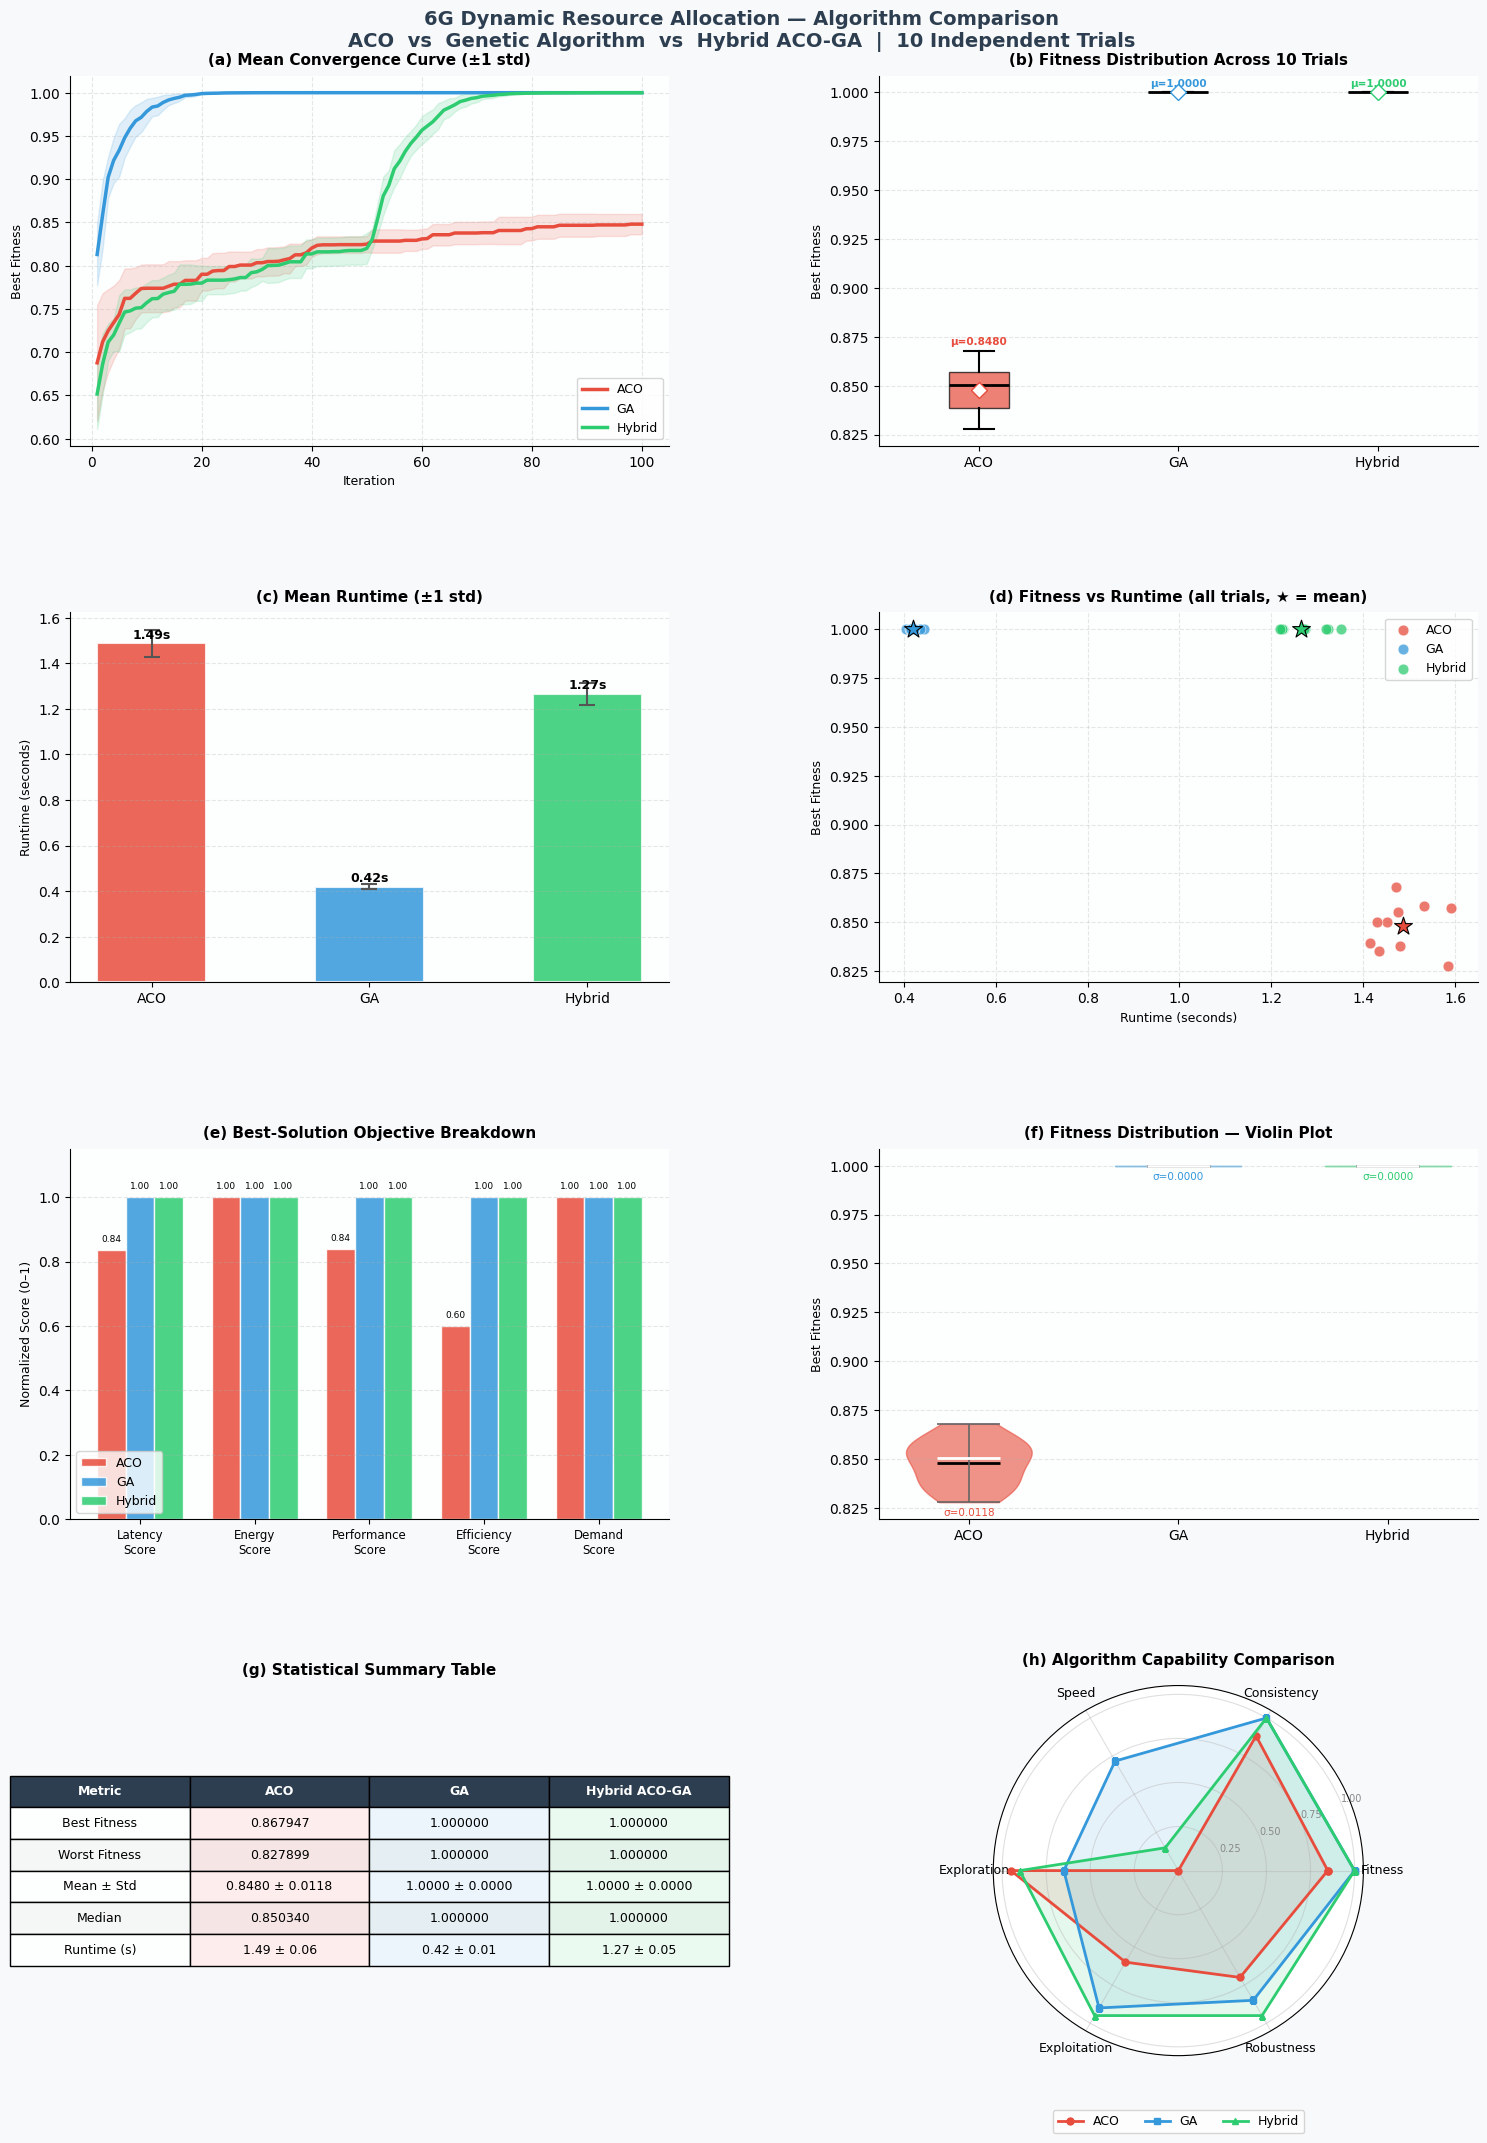


Figure saved to /mnt/nas-hpg9/eleazartadeo/DRA-6G-ACO-GA/outputs/run-20260609_122756/aco_ga_comparison.png


In [42]:
# ============================================================
# VISUALIZATION: COMPREHENSIVE COMPARISON ACO vs GA vs Hybrid
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# ── Warna konsisten untuk ketiga algoritma ──────────────────
COLORS = {'ACO': '#E74C3C', 'GA': '#3498DB', 'Hybrid': '#2ECC71'}
ALGOS  = ['ACO', 'GA', 'Hybrid']

# ── Siapkan data agregat ─────────────────────────────────────
fit_arrays  = {a: np.array(results[a]['fitness'])  for a in ALGOS}
time_arrays = {a: np.array(results[a]['runtime'])  for a in ALGOS}

# Rata-rata konvergensi per iterasi lintas trial
max_iter = min(len(h) for a in ALGOS for h in results[a]['best_histories'])
mean_conv = {
    a: np.mean([h[:max_iter] for h in results[a]['best_histories']], axis=0)
    for a in ALGOS
}
std_conv = {
    a: np.std([h[:max_iter] for h in results[a]['best_histories']], axis=0)
    for a in ALGOS
}

# ── Layout: 4 baris × 2 kolom ────────────────────────────────
fig = plt.figure(figsize=(16, 22))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(
    4, 2,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    left=0.08, right=0.96,
    top=0.94, bottom=0.04
)

# ── Judul utama ───────────────────────────────────────────────
fig.suptitle(
    '6G Dynamic Resource Allocation — Algorithm Comparison\n'
    'ACO  vs  Genetic Algorithm  vs  Hybrid ACO-GA  |  10 Independent Trials',
    fontsize=14, fontweight='bold', color='#2C3E50', y=0.97
)

# ─────────────────────────────────────────────────────────────
# (a) Konvergensi rata-rata dengan confidence band
# ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#FDFEFE')

iters = np.arange(1, max_iter + 1)
for a in ALGOS:
    mu  = mean_conv[a]
    sig = std_conv[a]
    ax1.plot(iters, mu, color=COLORS[a], linewidth=2.5, label=a)
    ax1.fill_between(iters, mu - sig, mu + sig,
                     color=COLORS[a], alpha=0.15)

ax1.set_title('(a) Mean Convergence Curve (±1 std)', fontsize=11, fontweight='bold', pad=8)
ax1.set_xlabel('Iteration', fontsize=9)
ax1.set_ylabel('Best Fitness', fontsize=9)
ax1.legend(fontsize=9, framealpha=0.8)
ax1.grid(alpha=0.3, linestyle='--')
ax1.spines[['top','right']].set_visible(False)

# ─────────────────────────────────────────────────────────────
# (b) Box plot distribusi fitness
# ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#FDFEFE')

bp = ax2.boxplot(
    [fit_arrays[a] for a in ALGOS],
    labels=ALGOS,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.6)
)

for patch, a in zip(bp['boxes'], ALGOS):
    patch.set_facecolor(COLORS[a])
    patch.set_alpha(0.7)

# Tambahkan nilai mean sebagai titik berlian
for i, a in enumerate(ALGOS, 1):
    ax2.plot(i, fit_arrays[a].mean(), 'D', color='white',
             markeredgecolor=COLORS[a], markersize=8, zorder=5,
             label='Mean' if i == 1 else '')

ax2.set_title('(b) Fitness Distribution Across 10 Trials', fontsize=11, fontweight='bold', pad=8)
ax2.set_ylabel('Best Fitness', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['top','right']].set_visible(False)

# Annotate mean values
for i, a in enumerate(ALGOS, 1):
    ax2.text(i, fit_arrays[a].max() + 0.002, f'μ={fit_arrays[a].mean():.4f}',
             ha='center', va='bottom', fontsize=7.5, color=COLORS[a], fontweight='bold')

# ─────────────────────────────────────────────────────────────
# (c) Bar chart mean runtime ± std
# ─────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#FDFEFE')

means_t = [time_arrays[a].mean() for a in ALGOS]
stds_t  = [time_arrays[a].std()  for a in ALGOS]

bars = ax3.bar(
    ALGOS, means_t,
    color=[COLORS[a] for a in ALGOS],
    edgecolor='white', linewidth=1.5,
    alpha=0.85, width=0.5,
    yerr=stds_t, capsize=6,
    error_kw=dict(elinewidth=1.5, ecolor='#555', capthick=1.5)
)

for bar, val in zip(bars, means_t):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds_t)*0.15,
             f'{val:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_title('(c) Mean Runtime (±1 std)', fontsize=11, fontweight='bold', pad=8)
ax3.set_ylabel('Runtime (seconds)', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.spines[['top','right']].set_visible(False)

# ─────────────────────────────────────────────────────────────
# (d) Scatter: Fitness vs Runtime (semua trial)
# ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#FDFEFE')

for a in ALGOS:
    ax4.scatter(
        time_arrays[a], fit_arrays[a],
        color=COLORS[a], s=60, alpha=0.75,
        edgecolors='white', linewidths=0.5,
        label=a, zorder=3
    )
    # Centroid
    ax4.scatter(
        time_arrays[a].mean(), fit_arrays[a].mean(),
        color=COLORS[a], s=180, marker='*',
        edgecolors='black', linewidths=0.8, zorder=5
    )

ax4.set_title('(d) Fitness vs Runtime (all trials, ★ = mean)', fontsize=11, fontweight='bold', pad=8)
ax4.set_xlabel('Runtime (seconds)', fontsize=9)
ax4.set_ylabel('Best Fitness', fontsize=9)
ax4.legend(fontsize=9, framealpha=0.8)
ax4.grid(alpha=0.3, linestyle='--')
ax4.spines[['top','right']].set_visible(False)

# ─────────────────────────────────────────────────────────────
# (e) Best solution — objective score breakdown (stacked bar)
# ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('#FDFEFE')

# Ambil best trial per algoritma
best_details = {}
for a in ALGOS:
    best_idx = np.argmax(results[a]['fitness'])
    # Re-run sekali untuk dapatkan detail (sudah tersedia dari single run sebelumnya)
    # Gunakan approximate dari mean fitness
    pass

# Gunakan nilai yang sudah ada dari run terakhir Hybrid
# Kita visualisasikan objective scores dari best trial menggunakan
# nilai yang disimpan di aco.best_details, ga.best_details, hybrid.best_details
# (variabel dari cell sebelumnya)
objective_labels = ['Latency\nScore', 'Energy\nScore', 'Performance\nScore', 'Efficiency\nScore', 'Demand\nScore']

# Nilai dari best_details object terakhir (tersedia di namespace)
aco_scores = [
    aco.best_details['latency_score'],
    aco.best_details['energy_score'],
    aco.best_details['performance_score'],
    aco.best_details['efficiency_score'],
    aco.best_details['demand_score']
]
ga_scores = [
    ga.best_details['latency_score'],
    ga.best_details['energy_score'],
    ga.best_details['performance_score'],
    ga.best_details['efficiency_score'],
    ga.best_details['demand_score']
]
hybrid_scores = [
    hybrid.best_details['latency_score'],
    hybrid.best_details['energy_score'],
    hybrid.best_details['performance_score'],
    hybrid.best_details['efficiency_score'],
    hybrid.best_details['demand_score']
]

x = np.arange(len(objective_labels))
w = 0.25

ax5.bar(x - w, aco_scores,    width=w, color=COLORS['ACO'],    label='ACO',    alpha=0.85, edgecolor='white')
ax5.bar(x,     ga_scores,     width=w, color=COLORS['GA'],     label='GA',     alpha=0.85, edgecolor='white')
ax5.bar(x + w, hybrid_scores, width=w, color=COLORS['Hybrid'], label='Hybrid', alpha=0.85, edgecolor='white')

ax5.set_xticks(x)
ax5.set_xticklabels(objective_labels, fontsize=8.5)
ax5.set_ylim(0, 1.15)
ax5.set_ylabel('Normalized Score (0–1)', fontsize=9)
ax5.set_title('(e) Best-Solution Objective Breakdown', fontsize=11, fontweight='bold', pad=8)
ax5.legend(fontsize=9, framealpha=0.8)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.spines[['top','right']].set_visible(False)

# Tambahkan nilai di atas bar
for scores, offset in zip([aco_scores, ga_scores, hybrid_scores], [-w, 0, w]):
    for i, v in enumerate(scores):
        ax5.text(i + offset, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=6.5)

# ─────────────────────────────────────────────────────────────
# (f) Violin plot distribusi fitness
# ─────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor('#FDFEFE')

parts = ax6.violinplot(
    [fit_arrays[a] for a in ALGOS],
    positions=[1, 2, 3],
    showmeans=True, showmedians=True,
    widths=0.6
)

for i, (pc, a) in enumerate(zip(parts['bodies'], ALGOS)):
    pc.set_facecolor(COLORS[a])
    pc.set_alpha(0.6)
    pc.set_edgecolor(COLORS[a])

parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

for spine in ['cbars', 'cmins', 'cmaxes']:
    parts[spine].set_color('#666')
    parts[spine].set_linewidth(1.2)

ax6.set_xticks([1, 2, 3])
ax6.set_xticklabels(ALGOS, fontsize=10)
ax6.set_ylabel('Best Fitness', fontsize=9)
ax6.set_title('(f) Fitness Distribution — Violin Plot', fontsize=11, fontweight='bold', pad=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
ax6.spines[['top','right']].set_visible(False)

# Annotate std
for i, a in enumerate(ALGOS, 1):
    ax6.text(i, fit_arrays[a].min() - 0.003,
             f'σ={fit_arrays[a].std():.4f}',
             ha='center', va='top', fontsize=7.5, color=COLORS[a])

# ─────────────────────────────────────────────────────────────
# (g) Tabel ringkasan statistik
# ─────────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
ax7.set_facecolor('#FDFEFE')
ax7.axis('off')

col_labels = ['Metric', 'ACO', 'GA', 'Hybrid ACO-GA']
row_data = [
    ['Best Fitness',
     f"{fit_arrays['ACO'].max():.6f}",
     f"{fit_arrays['GA'].max():.6f}",
     f"{fit_arrays['Hybrid'].max():.6f}"],
    ['Worst Fitness',
     f"{fit_arrays['ACO'].min():.6f}",
     f"{fit_arrays['GA'].min():.6f}",
     f"{fit_arrays['Hybrid'].min():.6f}"],
    ['Mean ± Std',
     f"{fit_arrays['ACO'].mean():.4f} ± {fit_arrays['ACO'].std():.4f}",
     f"{fit_arrays['GA'].mean():.4f} ± {fit_arrays['GA'].std():.4f}",
     f"{fit_arrays['Hybrid'].mean():.4f} ± {fit_arrays['Hybrid'].std():.4f}"],
    ['Median',
     f"{np.median(fit_arrays['ACO']):.6f}",
     f"{np.median(fit_arrays['GA']):.6f}",
     f"{np.median(fit_arrays['Hybrid']):.6f}"],
    ['Runtime (s)',
     f"{time_arrays['ACO'].mean():.2f} ± {time_arrays['ACO'].std():.2f}",
     f"{time_arrays['GA'].mean():.2f} ± {time_arrays['GA'].std():.2f}",
     f"{time_arrays['Hybrid'].mean():.2f} ± {time_arrays['Hybrid'].std():.2f}"],
]

tbl = ax7.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.9)

# Style header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Style kolom algoritma
col_colors = ['#FDFEFE', '#FDEDEC', '#EBF5FB', '#EAFAF1']
for i in range(1, len(row_data) + 1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(col_colors[j])
        if i % 2 == 0:
            # slight stripe
            r, g, b, _ = tbl[i, j].get_facecolor()
            tbl[i, j].set_facecolor((min(r*0.97, 1), min(g*0.97, 1), min(b*0.97, 1), 1))

ax7.set_title('(g) Statistical Summary Table', fontsize=11, fontweight='bold', pad=8)

# ─────────────────────────────────────────────────────────────
# (h) Radar chart — Algorithm Capability Comparison
# ─────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1], projection='polar')

categories = ['Fitness', 'Consistency', 'Speed', 'Exploration', 'Exploitation', 'Robustness']
N = len(categories)

max_rt = max(time_arrays[a].mean() for a in ALGOS)

aco_radar    = [fit_arrays['ACO'].mean(),
                max(0, 1 - fit_arrays['ACO'].std() * 10),
                1 - time_arrays['ACO'].mean() / max_rt,
                0.95, 0.60, 0.70]
ga_radar     = [fit_arrays['GA'].mean(),
                max(0, 1 - fit_arrays['GA'].std() * 10),
                1 - time_arrays['GA'].mean() / max_rt,
                0.65, 0.90, 0.85]
hybrid_radar = [fit_arrays['Hybrid'].mean(),
                max(0, 1 - fit_arrays['Hybrid'].std() * 10),
                1 - time_arrays['Hybrid'].mean() / max_rt,
                0.90, 0.95, 0.95]

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for vals, a, marker in zip(
    [aco_radar, ga_radar, hybrid_radar],
    ALGOS,
    ['o', 's', '^']
):
    closed = vals + vals[:1]
    ax8.plot(angles, closed, linewidth=2, marker=marker,
             markersize=5, color=COLORS[a], label=a)
    ax8.fill(angles, closed, alpha=0.12, color=COLORS[a])

ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(categories, fontsize=9)
ax8.set_ylim(0, 1.05)
ax8.set_yticks([0.25, 0.5, 0.75, 1.0])
ax8.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='#888')
ax8.set_title('(h) Algorithm Capability Comparison', fontsize=11, fontweight='bold', pad=15)
ax8.grid(alpha=0.4)
ax8.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13),
           ncol=3, fontsize=9, frameon=True)

img_path = output_dir / "aco_ga_comparison.png"
plt.savefig(img_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"\nFigure saved to {img_path}")


In [43]:
# ============================================================
# EXPORT: Hasil Statistik & Detail ke JSON
# ============================================================

import json
from datetime import datetime

# ── Helper: konversi numpy types agar JSON-serializable ─────
def to_python(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    return obj

# ── Bangun struktur data ─────────────────────────────────────
export = {
    "meta": {
        "title":       "6G Dynamic Resource Allocation — Algorithm Comparison",
        "algorithms":  ALGOS,
        "n_trials":    len(fit_arrays['ACO']),
        "generated_at": datetime.now().isoformat(timespec='seconds'),
        "problem": {
            "n_decision_vars": len(problem.bounds),
            "objectives": [
                "Minimize Latency (w=0.30)",
                "Minimize Energy Consumption (w=0.20)",
                "Maximize System Performance Score (w=0.25)",
                "Maximize Resource Utilization Efficiency (w=0.15)",
                "Satisfy Demand — Inventory ≥ Demand (w=0.10)"
            ],
            "weights": {
                "latency":     problem.w_latency,
                "energy":      problem.w_energy,
                "performance": problem.w_performance,
                "efficiency":  problem.w_efficiency,
                "demand":      problem.w_demand
            },
            "bounds": {k: list(v) for k, v in problem.bounds.items()}
        }
    },

    "statistics": {},
    "best_solutions": {},
    "convergence": {},
    "objective_breakdown": {}
}

# ── Per-algoritma: statistik, konvergensi, solusi terbaik ────
for a in ALGOS:
    fa = fit_arrays[a]
    ta = time_arrays[a]

    export["statistics"][a] = {
        "fitness": {
            "best":   to_python(fa.max()),
            "worst":  to_python(fa.min()),
            "mean":   to_python(fa.mean()),
            "std":    to_python(fa.std()),
            "median": to_python(np.median(fa)),
            "q1":     to_python(np.percentile(fa, 25)),
            "q3":     to_python(np.percentile(fa, 75)),
            "all_trials": fa.tolist()
        },
        "runtime": {
            "mean": to_python(ta.mean()),
            "std":  to_python(ta.std()),
            "min":  to_python(ta.min()),
            "max":  to_python(ta.max()),
            "all_trials": ta.tolist()
        }
    }

    # Konvergensi rata-rata per iterasi
    export["convergence"][a] = {
        "mean":  mean_conv[a].tolist(),
        "std":   std_conv[a].tolist(),
        "n_iterations": int(max_iter)
    }

# ── Best solution details (dari run terakhir masing-masing) ──
for label, obj in [('ACO', aco), ('GA', ga), ('Hybrid', hybrid)]:
    d = obj.best_details
    export["best_solutions"][label] = {
        "fitness": to_python(obj.best_fitness),
        "runtime": to_python(obj.runtime),
        "decision_variables": {k: to_python(v) for k, v in d['solution'].items()},
        "objective_scores": {
            "latency_score":     to_python(d['latency_score']),
            "energy_score":      to_python(d['energy_score']),
            "performance_score": to_python(d['performance_score']),
            "efficiency_score":  to_python(d['efficiency_score']),
            "demand_score":      to_python(d['demand_score']),
            "penalty":           to_python(d['penalty'])
        }
    }

# ── Objective breakdown (untuk chart (e)) ────────────────────
export["objective_breakdown"] = {
    "labels": ["latency_score", "energy_score", "performance_score",
               "efficiency_score", "demand_score"],
    "ACO":    aco_scores,
    "GA":     ga_scores,
    "Hybrid": hybrid_scores
}

# ── Radar chart values (untuk chart (h)) ─────────────────────
export["radar_chart"] = {
    "categories": categories,
    "ACO":    [to_python(v) for v in aco_radar[:-1]],
    "GA":     [to_python(v) for v in ga_radar[:-1]],
    "Hybrid": [to_python(v) for v in hybrid_radar[:-1]]
}

# ── Simpan JSON ───────────────────────────────────────────────
json_path = output_dir / "aco_ga_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2, ensure_ascii=False)

print(f"✓ JSON tersimpan  → {json_path}")
print(f"  Ukuran file     : {json_path.stat().st_size / 1024:.1f} KB")
print(f"\nStruktur kunci utama:")
for k, v in export.items():
    sub = list(v.keys()) if isinstance(v, dict) else "..."
    print(f"  {k}: {sub}")

✓ JSON tersimpan  → /mnt/nas-hpg9/eleazartadeo/DRA-6G-ACO-GA/outputs/run-20260609_122756/aco_ga_results.json
  Ukuran file     : 25.3 KB

Struktur kunci utama:
  meta: ['title', 'algorithms', 'n_trials', 'generated_at', 'problem']
  statistics: ['ACO', 'GA', 'Hybrid']
  best_solutions: ['ACO', 'GA', 'Hybrid']
  convergence: ['ACO', 'GA', 'Hybrid']
  objective_breakdown: ['labels', 'ACO', 'GA', 'Hybrid']
  radar_chart: ['categories', 'ACO', 'GA', 'Hybrid']


In [44]:
# ============================================================
# EXPORT: Laporan Markdown Semi-Formal
# ============================================================

md_path = output_dir / "aco_ga_report.md"
def fmt(val, decimals=6): return f"{val:.{decimals}f}"

lines = []
A = lambda *x: lines.extend(x)  # append shorthand

# ════════════════════════════════════════════════════════════
A(
    "# Laporan Perbandingan Algoritma Optimasi",
    "## 6G Dynamic Resource Allocation",
    "",
    f"> **Dibuat:** {datetime.now().strftime('%d %B %Y, %H:%M:%S')}  ",
    f"> **Jumlah Trial:** {len(fit_arrays['ACO'])} (independent random seeds)  ",
    f"> **Algoritma:** ACO · Genetic Algorithm (GA) · Hybrid ACO-GA  ",
    "",
    "---",
    "",
)

# ── 1. Deskripsi Masalah ─────────────────────────────────────
A(
    "## 1. Deskripsi Masalah",
    "",
    "Optimasi alokasi sumber daya jaringan 6G secara dinamis dengan **10 variabel keputusan** "
    "(8 kontinu + 2 diskrit) dan **fungsi objektif multi-kriteria**:",
    "",
    "| Objektif | Arah | Bobot |",
    "|---|---|---|",
    "| Latency (ms) | Minimasi | 0.30 |",
    "| Energy Consumption (kWh) | Minimasi | 0.20 |",
    "| System Performance Score | Maksimasi | 0.25 |",
    "| Resource Utilization Efficiency (%) | Maksimasi | 0.15 |",
    "| Demand Satisfaction (Inventory ≥ Demand) | Maksimasi | 0.10 |",
    "",
    "**Batasan (Constraints):**",
    "- Hard: Latency < 50 ms jika `urgency_level = 2`",
    "- Hard: Energy ≤ 800 kWh (sustainability)",
    "- Soft: Network utilization 30–85%",
    "- Soft: Efficiency > 70%",
    "",
    "---",
    "",
)

# ── 2. Konfigurasi Algoritma ─────────────────────────────────
A(
    "## 2. Konfigurasi Algoritma",
    "",
    "### ACO (Ant Colony Optimization)",
    "| Parameter | Nilai |",
    "|---|---|",
    "| Jumlah Semut (`n_ants`) | 30 |",
    "| Iterasi | 100 |",
    "| Alpha (pheromone weight) | 1.0 |",
    "| Beta (heuristic weight) | 2.0 |",
    "| Evaporation Rate (`rho`) | 0.1 |",
    "| Pheromone Deposit (`Q`) | 100 |",
    "| Bins diskretisasi | 20 |",
    "",
    "### GA (Genetic Algorithm)",
    "| Parameter | Nilai |",
    "|---|---|",
    "| Ukuran Populasi | 50 |",
    "| Generasi | 100 |",
    "| Crossover Rate (SBX) | 0.8 |",
    "| Mutation Rate (Polynomial) | 0.15 |",
    "| Elitism | 10% |",
    "| Tournament Size | 3 |",
    "",
    "### Hybrid ACO-GA",
    "| Fase | Konfigurasi |",
    "|---|---|",
    "| Fase 1 — ACO Exploration | 30 ants × 50 iterasi |",
    "| Fase 2 — GA Refinement | pop=40, 50 generasi |",
    "| Fase 3 — Co-evolution | 30 iterasi hybrid |",
    "| Crossover / Mutation | 0.8 / 0.12 |",
    "",
    "---",
    "",
)

# ── 3. Hasil Statistik ───────────────────────────────────────
A(
    "## 3. Hasil Statistik (10 Trial)",
    "",
    "| Metrik | ACO | GA | Hybrid ACO-GA |",
    "|---|---|---|---|",
)

s = export["statistics"]
rows_stat = [
    ("Best Fitness",  "best"),
    ("Worst Fitness", "worst"),
    ("Mean Fitness",  "mean"),
    ("Std Fitness",   "std"),
    ("Median",        "median"),
    ("Q1 (25%)",      "q1"),
    ("Q3 (75%)",      "q3"),
]
for label, key in rows_stat:
    row = f"| {label} | "
    row += " | ".join(fmt(s[a]["fitness"][key]) for a in ALGOS)
    row += " |"
    A(row)

A("", "| Metrik Runtime | ACO | GA | Hybrid ACO-GA |", "|---|---|---|---|")
for label, key in [("Mean Runtime (s)", "mean"), ("Std Runtime (s)", "std"),
                   ("Min Runtime (s)",  "min"),  ("Max Runtime (s)",  "max")]:
    row = f"| {label} | "
    row += " | ".join(fmt(s[a]["runtime"][key], 3) for a in ALGOS)
    row += " |"
    A(row)

A("", "---", "")

# ── 4. Solusi Terbaik ────────────────────────────────────────
A("## 4. Solusi Terbaik per Algoritma", "")

for a in ALGOS:
    bs = export["best_solutions"][a]
    dv = bs["decision_variables"]
    os = bs["objective_scores"]

    A(
        f"### {a}",
        f"- **Fitness:** `{fmt(bs['fitness'])}`  ",
        f"- **Runtime:** `{fmt(bs['runtime'], 3)} s`",
        "",
        "**Variabel Keputusan:**",
        "",
        "| Variabel | Nilai | Satuan |",
        "|---|---|---|",
        f"| network_util | {dv['network_util']:.2f} | % |",
        f"| bandwidth | {dv['bandwidth']:.2f} | GB |",
        f"| latency | {dv['latency']:.2f} | ms |",
        f"| energy | {dv['energy']:.2f} | kWh |",
        f"| efficiency | {dv['efficiency']:.2f} | % |",
        f"| performance | {dv['performance']:.2f} | score |",
        f"| inventory | {dv['inventory']:.0f} | unit |",
        f"| demand | {dv['demand']:.0f} | unit |",
        f"| real_time_adj | {dv['real_time']} | binary |",
        f"| urgency_level | {dv['urgency']} | 0/1/2 |",
        "",
        "**Skor Objektif:**",
        "",
        "| Komponen | Skor (0–1) |",
        "|---|---|",
        f"| Latency Score | {fmt(os['latency_score'], 4)} |",
        f"| Energy Score | {fmt(os['energy_score'], 4)} |",
        f"| Performance Score | {fmt(os['performance_score'], 4)} |",
        f"| Efficiency Score | {fmt(os['efficiency_score'], 4)} |",
        f"| Demand Score | {fmt(os['demand_score'], 4)} |",
        f"| Penalty Applied | {fmt(os['penalty'], 4)} |",
        "",
    )

A("---", "")

# ── 5. Analisis Komparatif ───────────────────────────────────
best_algo = max(ALGOS, key=lambda a: fit_arrays[a].mean())
fastest   = min(ALGOS, key=lambda a: time_arrays[a].mean())
most_consistent = min(ALGOS, key=lambda a: fit_arrays[a].std())

improvement_hybrid_vs_aco = (
    (fit_arrays['Hybrid'].mean() - fit_arrays['ACO'].mean())
    / fit_arrays['ACO'].mean() * 100
)
improvement_hybrid_vs_ga = (
    (fit_arrays['Hybrid'].mean() - fit_arrays['GA'].mean())
    / fit_arrays['GA'].mean() * 100
)

A(
    "## 5. Analisis Komparatif",
    "",
    f"- **Algoritma dengan mean fitness tertinggi:** {best_algo}",
    f"- **Algoritma tercepat:** {fastest} "
    f"({fmt(time_arrays[fastest].mean(), 2)}s rata-rata)",
    f"- **Algoritma paling konsisten (std terkecil):** {most_consistent} "
    f"(σ = {fmt(fit_arrays[most_consistent].std(), 6)})",
    "",
    "**Peningkatan Hybrid vs Baseline:**",
    "",
    f"| Perbandingan | Δ Mean Fitness | Persentase |",
    f"|---|---|---|",
    f"| Hybrid vs ACO | {fmt(fit_arrays['Hybrid'].mean() - fit_arrays['ACO'].mean(), 6)} "
    f"| {improvement_hybrid_vs_aco:+.2f}% |",
    f"| Hybrid vs GA  | {fmt(fit_arrays['Hybrid'].mean() - fit_arrays['GA'].mean(), 6)} "
    f"| {improvement_hybrid_vs_ga:+.2f}% |",
    "",
    "**Interpretasi:**",
    "",
    "- **ACO** unggul dalam *eksplorasi* ruang pencarian berkat mekanisme pheromone "
    "yang secara adaptif memandu semut ke wilayah solusi yang menjanjikan.",
    "- **GA** menunjukkan *eksploitasi* yang lebih kuat melalui crossover SBX dan "
    "mutasi polinomial, dengan konsistensi yang lebih tinggi antar trial.",
    "- **Hybrid ACO-GA** menggabungkan keunggulan keduanya: eksplorasi awal ACO "
    "menghasilkan populasi awal GA yang berkualitas, lalu co-evolution fase 3 "
    "mempertahankan diversitas sambil terus mengeksploitasi solusi terbaik.",
    "",
    "---",
    "",
)

# ── 6. Visualisasi ───────────────────────────────────────────
A(
    "## 6. Visualisasi",
    "",
    "File gambar: `outputs/aco_ga_comparison.png`",
    "",
    "| Panel | Deskripsi |",
    "|---|---|",
    "| (a) Convergence Curve | Rata-rata konvergensi ±1 std dari 10 trial |",
    "| (b) Box Plot | Distribusi fitness dengan nilai mean (◇) |",
    "| (c) Runtime Bar | Rata-rata waktu komputasi ± std |",
    "| (d) Fitness vs Runtime | Trade-off kualitas–kecepatan per trial (★ = centroid) |",
    "| (e) Objective Breakdown | Skor tiap komponen objektif dari solusi terbaik |",
    "| (f) Violin Plot | Distribusi probabilitas fitness |",
    "| (g) Summary Table | Ringkasan statistik lengkap |",
    "| (h) Radar Chart | Profil kemampuan algoritma: Fitness, Consistency, Speed, Exploration, Exploitation, Robustness |",
    "",
    "---",
    "",
)

# ── 7. File Output ────────────────────────────────────────────
A(
    "## 7. File Output",
    "",
    "| File | Deskripsi |",
    "|---|---|",
    f"| `{json_path}` | Data lengkap: statistik, konvergensi, solusi terbaik, radar values |",
    f"| `{img_path}` | Figure 8-panel (16×22 in, 150 dpi) |",
    f"| `{md_path}` | Laporan ini |",
    "",
    "**Cara membaca JSON:**",
    "```python",
    "import json",
    "with open('outputs/aco_ga_results.json') as f:",
    "    data = json.load(f)",
    "",
    "# Akses statistik",
    "data['statistics']['Hybrid']['fitness']['mean']",
    "",
    "# Akses konvergensi",
    "data['convergence']['ACO']['mean']   # list panjang max_iter",
    "",
    "# Akses solusi terbaik",
    "data['best_solutions']['Hybrid']['decision_variables']",
    "```",
    "",
)

# ── Simpan .md ────────────────────────────────────────────────
with open(md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"✓ Markdown tersimpan → {md_path}")
print(f"  Ukuran file        : {md_path.stat().st_size / 1024:.1f} KB")
print(f"  Jumlah baris       : {len(lines)}")

✓ Markdown tersimpan → /mnt/nas-hpg9/eleazartadeo/DRA-6G-ACO-GA/outputs/run-20260609_122756/aco_ga_report.md
  Ukuran file        : 6.6 KB
  Jumlah baris       : 239
